In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings
import mne  

In [18]:
# Ruta de tu archivo
file_path = "..\data\A01E.gdf"

# Leer el archivo .gdf
# preload=True carga los datos en RAM, necesario para aplicar filtros o cambios
raw = mne.io.read_raw_gdf(file_path, preload=True)

# 1. Ver metadatos generales (frecuencia de muestreo, canales, etc.)
print(raw.info)

# 2. Listar los nombres de los canales
print(f"Canales detectados: {raw.ch_names}")

# 3. Ver la duración y n de muestras
print(f"Duración: {raw.times[-1]} segundos")

Extracting GDF parameters from ..\data\A01E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 686999  =      0.000 ...  2747.996 secs...


<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Pc\AppData\Local\Temp\ipykernel_20376\1358716135.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  file_path = "..\data\A01E.gdf"
C:\Users\Pc\AppData\Local\Programs\Python\Python314\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-19 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-19>
>
Canales detectados: ['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']
Duración: 2747.996 segundos


Using matplotlib as 2D backend.


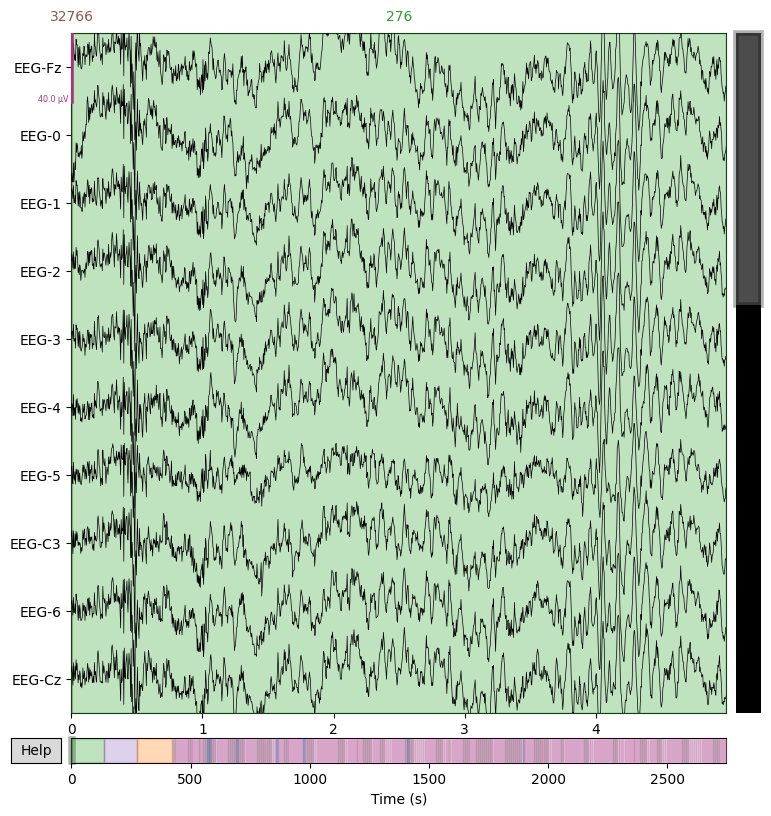

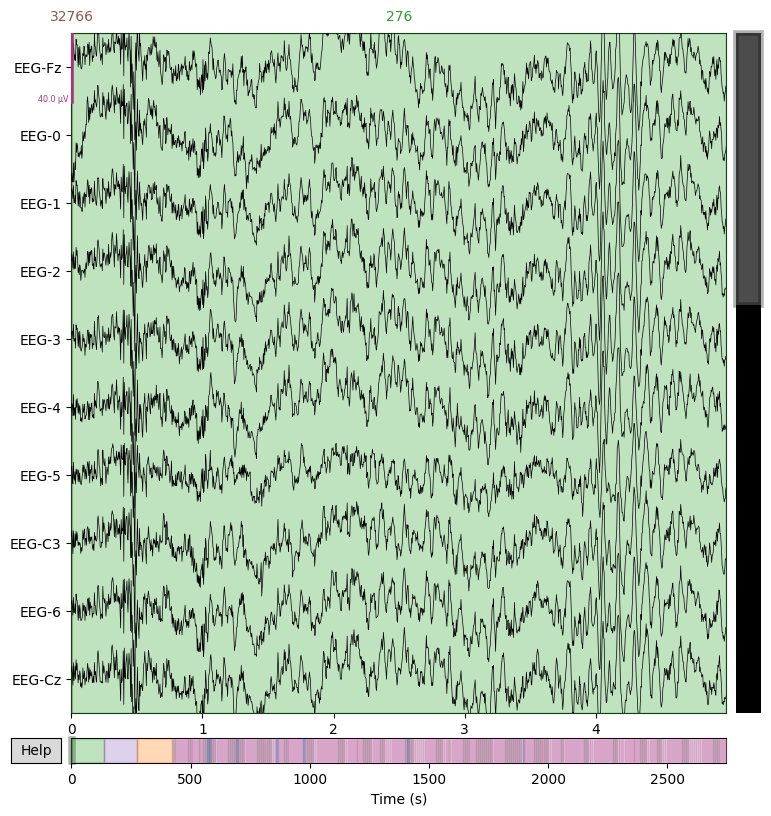

In [19]:
# Abre una ventana interactiva
# 'n_channels' define cuántos canales ver a la vez
# 'duration' define cuántos segundos de la línea de tiempo mostrar
raw.plot(n_channels=10, duration=5, title="Señales en el tiempo", show_scrollbars=True)

In [23]:
# Ver el resumen de la estructura
print(raw.info)

# Ver específicamente los tipos de canales
from collections import Counter
print(Counter(raw.get_channel_types()))

<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-19 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-19>
>
Counter({'eeg': 25})


In [ ]:
# Convertir a DataFrame
df = raw.to_data_frame()

# Si prefieres que el tiempo sea el índice del DataFrame:
df_con_indice = raw.to_data_frame(index='time')

# Inspección rápida
print(df.head())
print(f"Columnas resultantes: {df.columns.tolist()}")

## Sección n°1

- Sección que muestra paso a paso como se desglosa las diferentes funciones para filtrar y seccionar las señales de BCI.

In [2]:
# Instalamos las librerias necesarias para poder procesar estas señales:
import numpy as np
import scipy.io as sio
import scipy.signal as signal
from mne.io import read_raw_gdf
from mne import events_from_annotations
import glob
import logging

In [ ]:
# agregamos las funciones que son para filtrar:

from scipy import signal


# La primera es Filtro Notch (Eliminación de Interferencia Eléctrica)
def get_notch_filter_coef(fs):
    # Notch filter at 50 Hz
    # Definimos el rango de parada (bandstop) entre 49 Hz y 51 Hz
    w0 = [49.0/(fs/2), 51.0/(fs/2)] 
    # Diseñamos un filtro Butterworth de orden 8
    return signal.butter(8, w0, btype='bandstop')


# Ejemplo de uso
fs = 250
b, a = get_notch_filter_coef(fs)

print(f"b (coeficientes del numerador): {b[:3]}...")
print(f"a (coeficientes del denominador): {a[:3]}...") 

b (coeficientes del numerador): [ 0.87911129 -4.34793836 16.44096937]...
a (coeficientes del denominador): [ 1.         -4.86619064 18.10265353]...


¿Qué ocurre? Estos coeficientes son como las "instrucciones" de una receta. El vector b dice cómo ponderar las muestras actuales de la señal, y a dice cómo ponderar las salidas anteriores.

In [ ]:
# Filtro FIR (Finite Impulse Response)
def get_fir_filter_coef(order, freq_band=(48,52), fs=250, type= 'bandstop'):
    # Diseña los coeficientes de un filtro usando una ventana (window method)
    fir_coeff = signal.firwin(order + 1,[freq_band[48],freq_band[52]],pass_zero='type',fs=fs)
    return fir_coeff, 1.0

